In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import os

from kornia.augmentation.auto.autoaugment.ops import color

from hloc.utils.viz import save_plot

os.environ['PROJ_LIB'] = '/home/lty/anaconda3/envs/hloc/share/proj'

from osgeo import gdal, osr
from geopy.distance import geodesic

from hloc import extract_features, match_features
from hloc.utils.io import get_matches, get_keypoints
from hloc.visualization import plot_images, plot_keypoints, plot_matches, read_image, add_text

/home/lty/anaconda3/envs/hloc/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


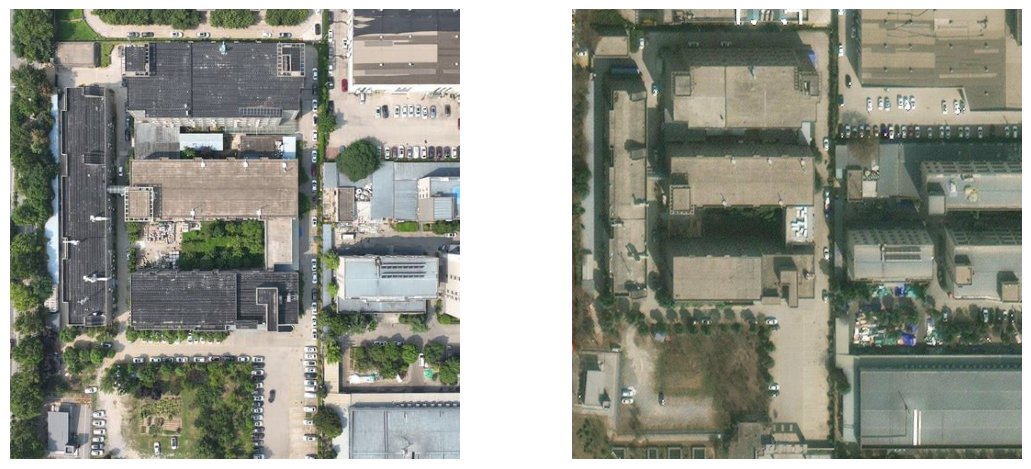

In [5]:
import os
image_dir = Path("//home/lty/code/Hierarchical-Localization/datasets/city3")
img_1 = "mapping/020.jpg"
img_2 = "tif/146_406_1606.tif"
# img_2 = "seu_uav/DJI_20250109085917_0001_W.JPG"
img_list = [img_1, img_2]
plot_images([read_image(image_dir / img_1), read_image(image_dir / img_2)])

In [6]:
output_dir = Path("output_elevation")
output_dir.mkdir(exist_ok=True, parents=True)
pairs_path = output_dir / "pairs.txt"

# for the first round of feature extraction and matching
features_1_path = output_dir / "features_1.h5"
matches_1_path = output_dir / "matches_1.h5"

In [7]:
# create pairs file
with open(pairs_path, 'w') as file:
    file.write(f"{img_1} {img_2}")

In [8]:
import time
t1 = time.time()
extract_features.main(
    conf=extract_features.confs["superpoint_max"],
    image_dir=image_dir,
    image_list=img_list,
    feature_path=features_1_path,
)
t2 = time.time()
match_features.main(
    conf=match_features.confs["superpoint+lightglue"],
    pairs=pairs_path,
    features=features_1_path,
    matches=matches_1_path,
)
t3 = time.time()
print(f"特征提取耗时：{t2 - t1:.2f} 秒")
print(f"特征匹配耗时：{t3 - t2:.2f} 秒")

[2025/05/26 16:16:13 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}
[2025/05/26 16:16:13 hloc INFO] Skipping the extraction.
[2025/05/26 16:16:13 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2025/05/26 16:16:13 hloc INFO] Skipping the matching.


特征提取耗时：0.02 秒
特征匹配耗时：0.00 秒


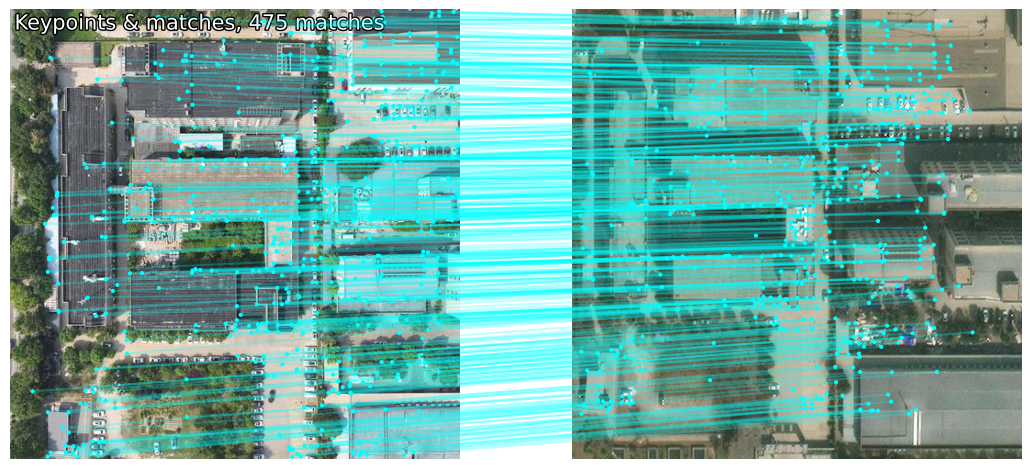

In [9]:
kp1, kp2  = get_keypoints(features_1_path, img_1), get_keypoints(features_1_path, img_2)
matches, scores = get_matches(matches_1_path, img_1, img_2)
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(kp1[matches[:,0]], kp2[matches[:,1]], a=0.25, color=(0, 1, 1))
add_text(0, f"Keypoints & matches, {matches.shape[0]} matches")
#save the plot
plt.savefig("matches.png", bbox_inches="tight", pad_inches=0, transparent=False)

In [113]:
print(kp1.shape)
print(kp2.shape)
print(matches.shape)
print(scores.shape)
scores

(3861, 2)
(1877, 2)
(460, 2)
(460,)


array([0.1866 , 0.3623 , 0.5967 , 0.3743 , 0.1497 , 0.3374 , 0.1371 ,
       0.1405 , 0.5156 , 0.2227 , 0.269  , 0.4355 , 0.10956, 0.2805 ,
       0.6133 , 0.1045 , 0.7314 , 0.1536 , 0.4995 , 0.3823 , 0.2817 ,
       0.2413 , 0.1294 , 0.4292 , 0.265  , 0.9736 , 0.2042 , 0.1179 ,
       0.643  , 0.2009 , 0.1711 , 0.1967 , 0.952  , 0.4175 , 0.5273 ,
       0.1191 , 0.2449 , 0.1268 , 0.3271 , 0.12   , 0.2383 , 0.7163 ,
       0.1747 , 0.1409 , 0.254  , 0.2413 , 0.796  , 0.1802 , 0.5615 ,
       0.1565 , 0.4946 , 0.3865 , 0.366  , 0.7534 , 0.221  , 0.874  ,
       0.6626 , 0.1016 , 0.969  , 0.7104 , 0.1038 , 0.3835 , 0.2413 ,
       0.3901 , 0.641  , 0.9937 , 0.784  , 0.9844 , 0.1484 , 0.2025 ,
       0.9067 , 0.7944 , 0.1348 , 0.1934 , 0.1598 , 0.3513 , 0.4607 ,
       0.2866 , 0.1298 , 0.4927 , 0.4067 , 0.4187 , 0.319  , 0.1896 ,
       0.2013 , 0.2869 , 0.1289 , 0.371  , 0.262  , 0.37   , 0.4329 ,
       0.3977 , 0.209  , 0.5557 , 0.102  , 0.12244, 0.1719 , 0.2798 ,
       0.824  , 0.56

[[-1.07780093e-07 -5.70688429e-05  2.80981672e-02]
 [ 5.70983864e-05  6.89070113e-07 -2.06899853e-02]
 [-3.95712352e-02  2.66515495e-02  1.00000000e+00]]
280
内点数量：280/475


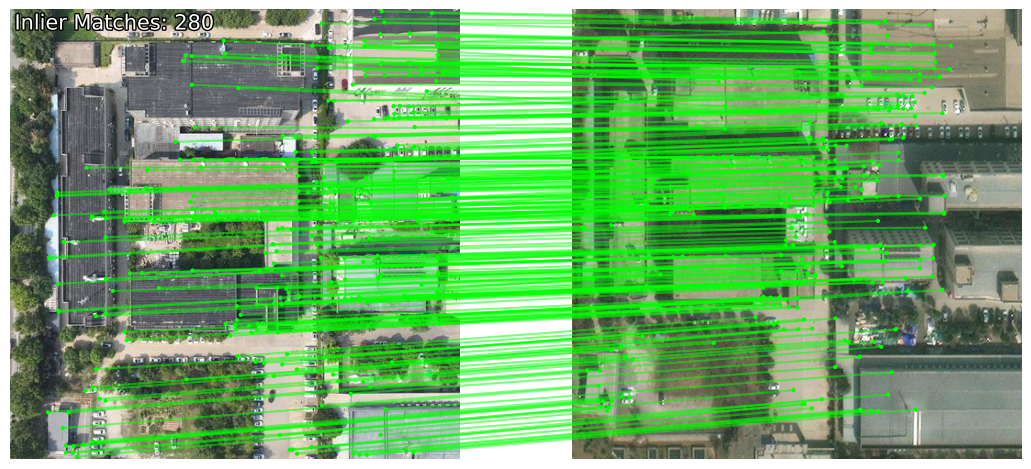

In [10]:
pts1 = kp1[matches[:, 0]]
pts2 = kp2[matches[:, 1]]

H, mask = cv2.findFundamentalMat(pts1, pts2, cv2.RANSAC, 3.0)  #mask:
print(H)
inliers = mask.ravel().tolist()
num_inliers = np.sum(inliers)
print(num_inliers)
# print(mask)

# 将 mask 转换为一维布尔数组
inliers = mask.ravel().astype(bool)

# 提取内点匹配对
pts1_inliers = pts1[inliers]
pts2_inliers = pts2[inliers]

# 提取外点匹配对（可选）
pts1_outliers = pts1[~inliers]
pts2_outliers = pts2[~inliers]

# 计算内点数量
num_inliers = np.sum(inliers)
print(f"内点数量：{num_inliers}/{len(pts1)}")

# 可视化内点匹配（例如，使用之前的 plot_matches 函数）
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(pts1_inliers, pts2_inliers, a=0.5, color=(0,1,0))
add_text(0, f"Inlier Matches: {num_inliers}")
plt.savefig("inlier_matches.png", bbox_inches="tight", pad_inches=0, transparent=False)

In [12]:
# translate to geographic coordinates
geotransform = []
# 打开 geotransform.txt 文件
with open("/home/lty/datasets/RealUAV/city3/geotransform.txt", "r") as f:
    # 逐行读取文件内容
    for line in f:
        # 去除行首尾的空白字符和换行符
        line = line.strip()
        if line:
            try:
                # 将字符串转换为浮点数
                value = float(line)
                # 将数值添加到列表中
                geotransform.append(value)
            except ValueError:
                print(f"无法将以下内容转换为数值：'{line}'")
                # 根据需要，可以选择跳过或停止程序
                continue
# 输出读取到的 geotransform 数据
print("Geotransform 数组：\n", geotransform)
tif_name = os.path.basename(img_2)
print(tif_name)
start_x = start_y = None
# 使用正则表达式匹配以数字开头的部分
match = re.match(r"(\d+)_(\d+)_(\d+).tif", tif_name)
if match:
    tif_id = match.group(1)
    start_x = match.group(2)
    start_y = match.group(3)
    print(f"TIFF ID: {tif_id}")
    print(f"起始横坐标：{start_x}")
    print(f"起始纵坐标：{start_y}")
else:
    print("无法从文件名中提取 TIFF ID")
    


x_geo, y_geo = None, None
pts2_inliers_geo = np.zeros((len(pts2_inliers), 2))

# 保存转换后的地理坐标
# --------------------------
geo_out_path = output_dir / "satellite_inlier_points_with_geo.txt"
# 获取仿射变换参数
x_origin, x_pixel_size, x_rotation, y_origin, y_rotation, y_pixel_size = geotransform

lu_geox = x_origin + float(start_x) * x_pixel_size
lu_geoy = y_origin + float(start_y) * y_pixel_size



with open(geo_out_path, 'w') as f:
    for idx, (x_pix, y_pix) in enumerate(pts2_inliers): 
        x_in_map = int(start_x) + x_pix
        y_in_map = int(start_y) + y_pix
        
        x_geo = x_origin + x_in_map * x_pixel_size
        y_geo = y_origin + y_in_map * y_pixel_size
        x_geo = x_geo-lu_geox
        y_geo = y_geo-lu_geoy
        
        pts2_inliers_geo[idx, 0] = x_geo
        pts2_inliers_geo[idx, 1] = y_geo
        
        
        f.write(f"{idx} {x_pix:.2f} {y_pix:.2f} {x_geo:.8f} {y_geo:.8f}\n")
        
        

Geotransform 数组：
 [12117256.345935825, 0.2985821417389691, 0.0, 4055825.1578397285, 0.0, -0.2985821417389691]
146_406_1606.tif
TIFF ID: 146
起始横坐标：406
起始纵坐标：1606


In [23]:
print(lu_geox,lu_geoy)

12117377.57028537 4055345.6349200956


In [9]:
print(pts2_inliers_geo)

[[ 159.44286369   -5.79902503]
 [ 182.13510646   -7.8051238 ]
 [ 155.71058692   -7.08666052]
 [ 160.78648333  -13.39887361]
 [ 131.52543344   -6.94670014]
 [ 172.13260471  -17.84028297]
 [ 159.29357262  -17.41107114]
 [ 184.07589038  -17.84028297]
 [ 192.88406356  -18.40945518]
 [  90.76897109  -29.29837266]
 [ 152.27689229  -19.55713028]
 [ 184.5237636   -22.28169233]
 [ 184.67305467  -22.86019523]
 [ 128.01709327  -11.38344415]
 [ 152.87405657  -22.28169233]
 [ 152.27689229  -21.8524805 ]
 [ 135.92952003  -19.83705104]
 [  92.93369162  -35.6059204 ]
 [  74.60821267  -34.03836416]
 [ 115.70057992  -32.0229347 ]
 [ 184.97163681  -26.87239276]
 [  77.85529346  -35.32599964]
 [ 130.62968701  -27.73081641]
 [  74.60821267  -36.89355589]
 [ 184.5237636   -29.87687556]
 [ 171.53544043  -29.5969548 ]
 [ 171.98331364  -29.87687556]
 [ 172.58047793  -29.87687556]
 [ 159.44286369  -29.29837266]
 [ 159.44286369  -29.87687556]
 [ 192.58548142  -30.45537846]
 [ 130.62968701  -31.59372287]
 [ 177.2

In [47]:
print(start_x,start_y)

406 1606


In [13]:
# 指定输出文件路径
match_save_path = output_dir / "satellite_uav_inliers.txt"

# 打开文件写入模式
with open(match_save_path, 'w') as f:
    for idx, (pt2_geo, pt2, pt1) in enumerate(zip(pts2_inliers_geo, pts2_inliers, pts1_inliers)):
        # pt2: 卫星影像特征点（目标图像）
        # pt1: 无人机影像特征点（参考图像）
        x2_geo, y2_geo = pt2_geo
        x2, y2 = pt2  # 卫星影像
        x1, y1 = pt1  # 无人机影像
        # 写入格式：索引 x2 y2 x1 y1
        f.write(f"{idx} {x2_geo:.8f} {y2_geo:.8f} {x2:.2f} {y2:.2f} {x1:.2f} {y1:.2f}\n")

print(f"内点匹配信息已保存至 {match_save_path}")


内点匹配信息已保存至 output_elevation/satellite_uav_inliers.txt


In [11]:
from hloc.utils.read_write_model import read_model
cameras, images, points3D = read_model('/home/lty/code/Hierarchical-Localization/outputs/city3/sfm')

In [12]:
from scipy.spatial import cKDTree
import numpy as np

def find_3d_points_with_ids_for_uav_inliers(pts1_inliers, images, image_id, points3D, pixel_thresh=2.0):
    """
    给定 UAV 图像的内点 pts1_inliers，找到在 COLMAP 中对应的三维点，并返回所有关联信息。

    返回：
        matched_ids       : 原始内点的索引（int）
        matched_2d        : UAV图像中的2D坐标 (N, 2)
        matched_3d        : 对应的三维空间坐标 (N, 3)
        matched_3d_ids    : 对应的3D点ID (N,)
    """
    image = images[image_id]
    xys_colmap = image.xys  # COLMAP 特征点坐标
    point3D_ids = image.point3D_ids  # 对应的3D点ID

    tree = cKDTree(xys_colmap)

    matched_ids = []
    matched_2d = []
    matched_3d = []
    matched_3d_ids = []

    for i, pt in enumerate(pts1_inliers):
        dist, idx = tree.query(pt, distance_upper_bound=pixel_thresh)

        # print(f"pt: {pt}, dist: {dist}")  # 输出距离以调试

        if idx < len(xys_colmap):
            pid = point3D_ids[idx]
            if pid != -1 and pid in points3D:
                xyz = points3D[pid].xyz
                matched_ids.append(i)            # 当前点在 pts1_inliers 中的索引
                matched_2d.append(pt)            # UAV像素点
                matched_3d.append(xyz)           # 对应3D点坐标
                matched_3d_ids.append(pid)       # 对应3D点ID

    matched_ids = np.array(matched_ids)
    matched_2d = np.array(matched_2d)
    matched_3d = np.array(matched_3d)
    matched_3d_ids = np.array(matched_3d_ids)

    print(f"\n共找到 {len(matched_3d)} 个有效2D-3D匹配点")
    return matched_ids, matched_2d, matched_3d, matched_3d_ids


image_id = 20  # 替换为你实际使用的无人机图像编号

matched_ids, matched_2d, matched_3d, matched_3d_ids = find_3d_points_with_ids_for_uav_inliers(
    pts1_inliers, images, image_id, points3D=points3D, pixel_thresh=1.0
)

# 保存为 csv 或 txt 格式
save_path = output_dir/"uav_2d_to_3d_matches.txt"
with open(save_path, 'w') as f:
    f.write("match_id uav_x uav_y X Y Z point3D_id\n")
    for i in range(len(matched_ids)):
        idx = matched_ids[i]
        x2d, y2d = matched_2d[i]
        X, Y, Z = matched_3d[i]
        pid = matched_3d_ids[i]
        f.write(f"{idx} {x2d:.2f} {y2d:.2f} {X:.6f} {Y:.6f} {Z:.6f} {pid}\n")


共找到 267 个有效2D-3D匹配点


In [13]:
matched_satellite_geos = pts2_inliers_geo[matched_ids]

In [14]:
def estimate_scale_least_squares_centered(geo_coords, model_coords):
    geo_center = np.mean(geo_coords, axis=0)
    model_center = np.mean(model_coords, axis=0)

    geo_zero = geo_coords - geo_center
    model_zero = model_coords - model_center

    numerator = np.sum(geo_zero * model_zero)
    denominator = np.sum(model_zero ** 2)

    if denominator < 1e-8:
        raise ValueError("地理坐标值过小或全相同，无法估计尺度")

    scale = numerator / denominator
    return scale

# matched_satellite_geos: (N, 2)
# matched_3d: (N, 3)
model_xy = matched_3d[:, :2]

scale = estimate_scale_least_squares_centered(matched_satellite_geos, model_xy)
print(f"估计得到的最优尺度因子: {scale}")

估计得到的最优尺度因子: -0.13664898525387087


In [15]:
import numpy as np

def estimate_scale_from_random_pairs_trimmed(geo_coords, model_coords, num_pairs=1000, seed=None, trim=10):
    """
    随机采样点对，剔除最大和最小的尺度后估计平均尺度。

    参数：
        geo_coords: (N, 2) 卫星地理坐标点
        model_coords: (N, 2) 对应的UAV模型坐标点
        num_pairs: 采样的点对数量
        seed: 随机种子
        trim: 剔除前/后 trim 个极端值（默认各剔除10个）

    返回：
        scale_mean: 剔除极端值后的均值
        scale_std:  标准差
        trimmed_scales: 剩下用于计算的 scale 值列表
    """
    assert geo_coords.shape == model_coords.shape
    N = geo_coords.shape[0]
    assert N >= 2, "至少需要两个点"

    if seed is not None:
        np.random.seed(seed)

    scales = []

    for _ in range(num_pairs):
        i, j = np.random.choice(N, 2, replace=False)

        d_geo = np.linalg.norm(geo_coords[i] - geo_coords[j])
        d_model = np.linalg.norm(model_coords[i] - model_coords[j])

        if d_geo > 1e-6 and d_model > 1e-6:
            scales.append(d_geo / d_model)

    if len(scales) < 2 * trim:
        raise ValueError("点对数量不足，无法剔除指定数量的极端值")

    scales_sorted = np.sort(scales)
    trimmed_scales = scales_sorted[trim: -trim]  # 去掉前后 trim 个

    scale_mean = np.mean(trimmed_scales)
    scale_std = np.std(trimmed_scales)

    return scale_mean, scale_std, trimmed_scales


geo_coords = matched_satellite_geos     # (N, 2)
model_coords = matched_3d[:, :2]        # (N, 2)

scale_mean, scale_std, scale_list = estimate_scale_from_random_pairs_trimmed(
    geo_coords, model_coords, num_pairs=1000, seed=42
)

print(f"随机点对估计尺度：mean = {scale_mean:.6f}, std = {scale_std:.6f}")


随机点对估计尺度：mean = 10.805196, std = 0.784202


In [16]:
def estimate_ground_z_flipped(Z_scaled, method='quantile', quantile=0.95):
    """
    用于原始 Z 是从空中指向地面的情况（Z越大越靠近地面）。
    """
    if method == 'max':
        return np.max(Z_scaled)
    elif method == 'quantile':
        return np.quantile(Z_scaled, quantile)
    elif method == 'mean':
        return np.mean(Z_scaled)
    else:
        raise ValueError("method must be 'quantile', 'max', or 'mean'")

def convert_model_z_to_geo_flipped(Z_model, scale, method='quantile', quantile=0.95):
    Z_scaled = Z_model * scale
    Z_ground = estimate_ground_z_flipped(Z_scaled, method, quantile)
    Z_final = Z_ground - Z_scaled  # 让地面为0，Z值越小越靠近相机
    return Z_final, Z_ground

Z_model = matched_3d[:, 2]
Z_final, Z_ground = convert_model_z_to_geo_flipped(Z_model, scale_mean)

print(f"估计地面Z = {Z_ground:.3f}")
print(f"Z_final范围: {Z_final.min():.2f} ~ {Z_final.max():.2f}")

# 升维构造完整三维地理点：
satellite_3d_final = np.hstack([matched_satellite_geos, Z_final[:, np.newaxis]])
print(f"地面高度估计值: {Z_ground:.4f}")
# print(satellite_3d_final)

估计地面Z = 456.518
Z_final范围: -5.97 ~ 46.93
地面高度估计值: 456.5181


In [17]:
output_path = output_dir / "satellite_3d_final.txt"
def save_3d_points_txt(points_3d, output_path):
    with open(output_path, 'w') as f:
        f.write("X_geo Y_geo Z_height\n")
        for pt in points_3d:
            f.write(f"{pt[0]:.3f} {pt[1]:.3f} {pt[2]:.3f}\n")
    print(f"已保存至：{output_path}")

save_3d_points_txt(satellite_3d_final, output_path)

已保存至：output_elevation/satellite_3d_final.txt


In [18]:
# (N, 3) 世界坐标（卫星地图下的三维点）
object_points = satellite_3d_final.astype(np.float32)

# (N, 2) 无人机图像上的像素坐标
image_points = matched_2d.astype(np.float32)
fx, fy = 537.0, 537.0   # 焦距
cx, cy = 245.0, 245.0     # 主点

K = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
], dtype=np.float32)


In [20]:
import cv2
# solvePnP：用来估计R, t
success, rvec, tvec = cv2.solvePnP(
    objectPoints=object_points,
    imagePoints=image_points,
    cameraMatrix=K,
    distCoeffs=None,  # 无畸变时设为 None
    flags=cv2.SOLVEPNP_SQPNP  # 可换成 EPNP/DLS/UPnP 等
)
# success, rvec, tvec, inliers = cv2.solvePnPRansac(
#     objectPoints=object_points,
#     imagePoints=image_points,
#     cameraMatrix=K,
#     distCoeffs=None,
#     iterationsCount=100,
#     reprojectionError=5.0,  # 像素阈值
#     confidence=0.8,
#     flags=cv2.SOLVEPNP_ITERATIVE
# )
# 
# # 提取 RANSAC 选出的内点
# object_points_inliers = object_points[inliers[:, 0]]
# image_points_inliers = image_points[inliers[:, 0]]
# 
# # 使用内点进行 refine（非必须，但能更准）
# success, rvec, tvec = cv2.solvePnP(
#     object_points_inliers, image_points_inliers, K, None,
#     flags=cv2.SOLVEPNP_ITERATIVE
# )



if success:
    R, _ = cv2.Rodrigues(rvec)  # 将旋转向量转换为矩阵
    camera_center = -R.T @ tvec

    print("位姿估计成功！")
    print("旋转矩阵 R:\n", R)
    print("平移向量 t:\n", tvec.ravel())
    print("相机中心（世界坐标系）:\n", camera_center.ravel())
else:
    print("solvePnP 失败，可能是点分布不均或共面")

projected_points, _ = cv2.projectPoints(
    object_points, rvec, tvec, K, distCoeffs=None)

projected_points = projected_points.reshape(-1, 2)

reproj_error = np.linalg.norm(projected_points - image_points, axis=1)
print("平均重投影误差：", np.mean(reproj_error), "像素")

camerax_geo = lu_geox -tvec[0, 0]
cameray_geo = lu_geoy +tvec[1, 0]
print(tvec)
print(camera_center)
print(f"相机中心地理坐标: ({camerax_geo:.4f}, {cameray_geo:.4f})")

# 使用 Levenberg-Marquardt 方法进一步优化位姿
rvec_refined, tvec_refined = cv2.solvePnPRefineLM(
    objectPoints=object_points,
    imagePoints=image_points,
    cameraMatrix=K,
    distCoeffs=None,        # 如果有畸变，这里传入畸变参数
    rvec=rvec,              # 初始旋转向量
    tvec=tvec,               # 初始平移向量
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_COUNT, 100, 1e-9)
)
R,_ = cv2.Rodrigues(rvec_refined)

# 输出优化后的位姿
print("优化后的旋转向量 rvec_refined:\n", rvec_refined.ravel())
print("优化后的平移向量 tvec_refined:\n", tvec_refined.ravel())

位姿估计成功！
旋转矩阵 R:
 [[ 0.99418559  0.00465645 -0.10757943]
 [-0.00434047 -0.99651963 -0.08324529]
 [-0.10759264  0.08322821 -0.99070525]]
平移向量 t:
 [ -92.30473159 -104.76223371  256.40867289]
相机中心（世界坐标系）:
 [ 118.90100322 -125.30824507  235.37436514]
平均重投影误差： 8.560908 像素
[[ -92.30473159]
 [-104.76223371]
 [ 256.40867289]]
[[ 118.90100322]
 [-125.30824507]
 [ 235.37436514]]
相机中心地理坐标: (12117469.8750, 4055240.8727)
优化后的旋转向量 rvec_refined:
 [ 3.05650446e+00  9.34864061e-04 -1.61655323e-01]
优化后的平移向量 tvec_refined:
 [ -92.31481835 -105.09420524  257.55211582]


In [21]:
import open3d as o3d
import numpy as np

def create_camera_frame(R, t, scale=0.5):
    """
    创建一个表示相机姿态的坐标系箭头（三维方向可视化）

    参数：
        R: (3, 3) 旋转矩阵（从世界到相机）
        t: (3, 1) 平移向量（从世界到相机）
        scale: 坐标轴的可视化大小

    返回：
        Open3D 三维坐标轴几何体
    """
    # 相机中心在世界坐标系的位置
    C = -R.T @ t  # shape: (3, 1)

    # 创建单位坐标轴（初始位于原点）
    camera_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=scale)

    # 将坐标轴旋转到相机方向（相机坐标系方向）
    camera_frame.rotate(R.T, center=(0, 0, 0))  # 注意要转置
    camera_frame.translate(C.ravel())  # 平移到相机位置

    return camera_frame

def visualize_camera_with_points(points_3d, R, tvec, scale=0.5):
    """
    可视化点云与相机朝向坐标轴
    """
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_3d)

    # 可选：Z高着色
    z_vals = points_3d[:, 2]
    norm_z = (z_vals - z_vals.min()) / (z_vals.ptp() + 1e-6)
    colors = plt.get_cmap('terrain')(norm_z)[:, :3]
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # 创建相机姿态箭头
    cam_frame = create_camera_frame(R, tvec, scale=scale)

    # 可视化
    vis = o3d.visualization.Visualizer()
    vis.create_window("Camera Pose Visualization", width=1280, height=800)
    vis.add_geometry(pcd)
    vis.add_geometry(cam_frame)

    # 坐标轴参考
    world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=scale)
    vis.add_geometry(world_frame)

    vis.run()
    vis.destroy_window()

visualize_camera_with_points(
    points_3d=satellite_3d_final,
    R=R,                # 你从 solvePnP 得到的旋转矩阵
    tvec=tvec,          # 你从 solvePnP 得到的平移向量
    scale=1.0           # 相机箭头大小
)



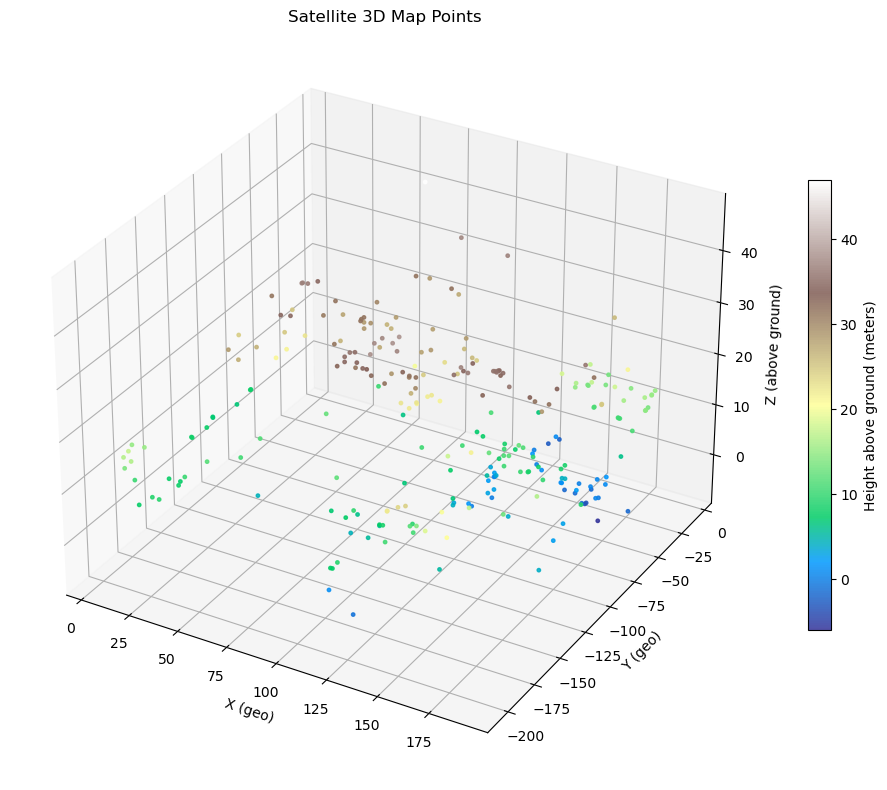

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def visualize_3d_geopoints(points_3d, elev_cmap='terrain', elev_alpha=0.85, elev_pointsize=6):
    """
    三维点可视化：X_geo, Y_geo, Z_above_ground
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    x = points_3d[:, 0]
    y = points_3d[:, 1]
    z = points_3d[:, 2]

    # 高度颜色映射
    sc = ax.scatter(x, y, z, c=z, cmap=elev_cmap, alpha=elev_alpha, s=elev_pointsize)

    # 添加颜色条
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label('Height above ground (meters)')

    ax.set_xlabel('X (geo)')
    ax.set_ylabel('Y (geo)')
    ax.set_zlabel('Z (above ground)')
    ax.set_title('Satellite 3D Map Points')

    plt.tight_layout()
    plt.show()
    
visualize_3d_geopoints(satellite_3d_final)

# 可视化三维地理点

In [ ]:
plt.hist(Z_final, bins=50, color='steelblue', edgecolor='k')
plt.axvline(0, color='red', linestyle='--', label="Estimated Ground (Z=0)")
plt.title("Z_final (相对于地面)")
plt.xlabel("Height Above Ground")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


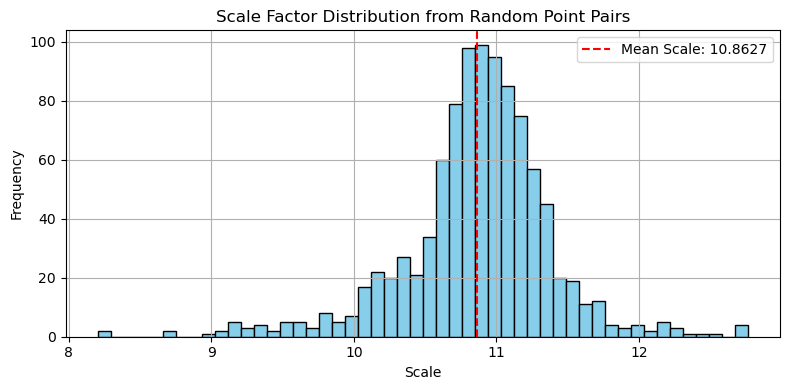

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(scale_list, bins=50, color='skyblue', edgecolor='k')
plt.axvline(scale_mean, color='red', linestyle='--', label=f"Mean Scale: {scale_mean:.4f}")
plt.title("Scale Factor Distribution from Random Point Pairs")
plt.xlabel("Scale")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("scale_distribution.png")
plt.show()


In [52]:
print(images)

{1: Image(id=1, qvec=array([ 9.99903411e-01,  1.36587508e-02, -4.58350189e-04, -2.52941285e-03]), tvec=array([-0.48043701, -6.24848373, -0.18996266]), camera_id=1, name='mapping/001.jpg', xys=array([[159.75      ,   2.60351562],
       [264.25      ,   2.60351562],
       [357.5       ,   2.60351562],
       ...,
       [174.75      , 487.        ],
       [ 41.5       , 487.5       ],
       [ 43.03125   , 487.5       ]]), point3D_ids=array([5551,  156, 4642, ...,   -1,   -1,   -1])), 2: Image(id=2, qvec=array([ 9.99899249e-01,  1.41620850e-02, -9.44254170e-04, -1.86420419e-04]), tvec=array([-0.41977217, -6.05341474, -0.1869615 ]), camera_id=2, name='mapping/002.jpg', xys=array([[130.875     ,   2.60351562],
       [134.625     ,   2.60351562],
       [167.375     ,   2.60351562],
       ...,
       [380.        , 487.5       ],
       [392.75      , 487.5       ],
       [485.25      , 487.5       ]]), point3D_ids=array([2632,  343, 7716, ...,   -1,   -1,   -1])), 3: Image(id=3, qvec

In [50]:
print(points3D)

{11433: Point3D(id=11433, xyz=array([-1.70438497, -2.39314798, 39.67596548]), rgb=array([91, 84, 78]), error=array(2.24516056), image_ids=array([13, 20, 12, 17, 21,  6,  5, 13,  4, 21,  5, 24]), point2D_idxs=array([1055, 1656,  874, 1368, 1684,  365,  266, 1089,   83, 1750,  291,
       2059])), 11431: Point3D(id=11431, xyz=array([ 4.81405846, -0.19410898, 41.42787845]), rgb=array([148, 143, 143]), error=array(2.37052214), image_ids=array([ 8, 23, 10, 15, 16, 14, 13, 12, 11, 18, 17, 19, 20, 21,  9, 22,  7,
        6,  5,  4,  3,  2,  1, 23, 10, 15, 16, 14, 13, 12, 11, 18, 17, 17,
       19, 20, 20, 21, 21,  9, 22,  1, 24, 24]), point2D_idxs=array([  69, 2366, 1338, 1717, 1854, 1547, 1613, 1461, 1393, 2041, 1869,
       2055, 2167, 2170, 1158, 2299,  328,  933,  838,  647,  497,  362,
        304, 2410, 1376, 1750, 1898, 1586, 1643, 1487, 1427, 2078, 1900,
       1903, 2085, 2199, 2212, 2213, 2217, 1180, 2330,  349, 2500, 2497])), 11430: Point3D(id=11430, xyz=array([ 0.58617332, 13.2216

In [51]:
print(cameras)

{1: Camera(id=1, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06055007e+03, 2.45000000e+02, 2.45000000e+02, 1.24624091e-01])), 2: Camera(id=2, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06086373e+03, 2.45000000e+02, 2.45000000e+02, 1.19332614e-01])), 3: Camera(id=3, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06183579e+03, 2.45000000e+02, 2.45000000e+02, 1.21027642e-01])), 4: Camera(id=4, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06061524e+03, 2.45000000e+02, 2.45000000e+02, 1.23271649e-01])), 5: Camera(id=5, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06056453e+03, 2.45000000e+02, 2.45000000e+02, 1.26673794e-01])), 6: Camera(id=6, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.05968229e+03, 2.45000000e+02, 2.45000000e+02, 1.26266489e-01])), 7: Camera(id=7, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06314883e+03, 2.45000000e+02, 2.45000000e+02, 1.23839552e-01]))